# ARTI406 - Assignment 2: Data Quality Assessment & Preprocessing

## Sleep Health and Lifestyle Dataset

This notebook uses the same dataset from Assignment 1.  
The goal is to check data quality issues, handle missing values and outliers, normalize numerical features, and apply PCA to understand how much information can be explained by fewer components.

## Assignment Tasks
- **Task 1:** Identify data quality issues in the dataset.
- **Task 2:** Apply one missing value strategy and explain why.
- **Task 3:** Detect and handle outliers using IQR.
- **Task 4:** Normalize numerical features using both Min-Max and Z-score.
- **Task 5:** Apply PCA and interpret explained variance.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [3]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (374, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage

# Task 1: Identify Data Quality Issues

First, I checked the dataset structure, missing values, duplicate rows, data types, and the unique values in categorical columns. This helps show what needs cleaning before doing preprocessing or PCA.

In [4]:
# Check missing values in each column
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

Sleep Disorder             219
Gender                       0
Age                          0
Occupation                   0
Person ID                    0
Sleep Duration               0
Quality of Sleep             0
Stress Level                 0
Physical Activity Level      0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
dtype: int64

In [5]:
# Check duplicate rows using all columns
df.duplicated().sum()

np.int64(0)

In [6]:
# Check repeated records after ignoring Person ID because it is just an identifier
repeated_profiles = df.drop(columns=["Person ID"]).duplicated().sum()
repeated_profiles

np.int64(242)

In [7]:
# Check data types
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [8]:
# Check categorical values
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 50)

Gender:
['Male' 'Female']
--------------------------------------------------
Occupation:
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
--------------------------------------------------
BMI Category:
['Overweight' 'Normal' 'Obese' 'Normal Weight']
--------------------------------------------------
Blood Pressure:
['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95' '139/91'
 '118/75']
--------------------------------------------------
Sleep Disorder:
[nan 'Sleep Apnea' 'Insomnia']
--------------------------------------------------


## Data Quality Issues Found

From the checks above, the main data quality issues are:

1. **Missing values:** The `Sleep Disorder` column has many missing values. In this dataset, the missing values most likely mean the person does not have a recorded sleep disorder.
2. **Blood Pressure format:** The `Blood Pressure` column is stored as text in the format `systolic/diastolic`, so it cannot be used directly as a numerical feature.
3. **BMI Category inconsistency:** The dataset has both `Normal` and `Normal Weight`, which describe a very similar category but are written differently.
4. **Repeated profiles:** There are repeated rows after removing `Person ID`. I did not remove them because `Person ID` shows they are different records, but it is still something to notice.
5. **Possible outliers:** Numerical columns need to be checked using IQR, especially `Heart Rate`.

## Basic Cleaning Before Preprocessing

I will make a copy of the dataset and clean the format issues without changing the original dataframe.

In [9]:
df_clean = df.copy()

# Standardize BMI category names so similar labels are treated as one category
df_clean["BMI Category"] = df_clean["BMI Category"].replace({"Normal Weight": "Normal"})

# Split Blood Pressure into two numerical columns
df_clean[["Systolic BP", "Diastolic BP"]] = df_clean["Blood Pressure"].str.split("/", expand=True).astype(int)

df_clean.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


# Task 2: Missing Value Strategy

I used **constant value imputation** for the `Sleep Disorder` column by replacing missing values with `No Disorder`.

I chose this strategy because the missing values are not numerical measurements like age or heart rate. They appear in a diagnosis-related column, so leaving them as `NaN` would make the column unclear. Replacing them with `No Disorder` makes the meaning easier and keeps all records in the dataset.

In [10]:
df_clean["Sleep Disorder"] = df_clean["Sleep Disorder"].fillna("No Disorder")

df_clean["Sleep Disorder"].value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [11]:
# Confirm there are no missing values after handling Sleep Disorder
df_clean.isna().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64

# Task 3: Detect and Handle Outliers Using IQR

The IQR method uses the middle 50% of the data to define the normal range:

- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are treated as outliers.

In [12]:
# Numerical columns used for preprocessing
numerical_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

outlier_summary = []

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.shape[0]
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,35.25,50.0,14.75,13.125,72.125,0
1,Sleep Duration,6.40,7.8,1.40,4.300,9.900,0
2,Quality of Sleep,6.00,8.0,2.00,3.000,11.000,0
3,Physical Activity Level,45.00,75.0,30.00,0.000,120.000,0
4,Stress Level,4.00,7.0,3.00,-0.500,11.500,0
5,Heart Rate,68.00,72.0,4.00,62.000,78.000,15
6,Daily Steps,5600.00,8000.0,2400.00,2000.000,11600.000,0
7,Systolic BP,125.00,135.0,10.00,110.000,150.000,0
8,Diastolic BP,80.00,90.0,10.00,65.000,105.000,0


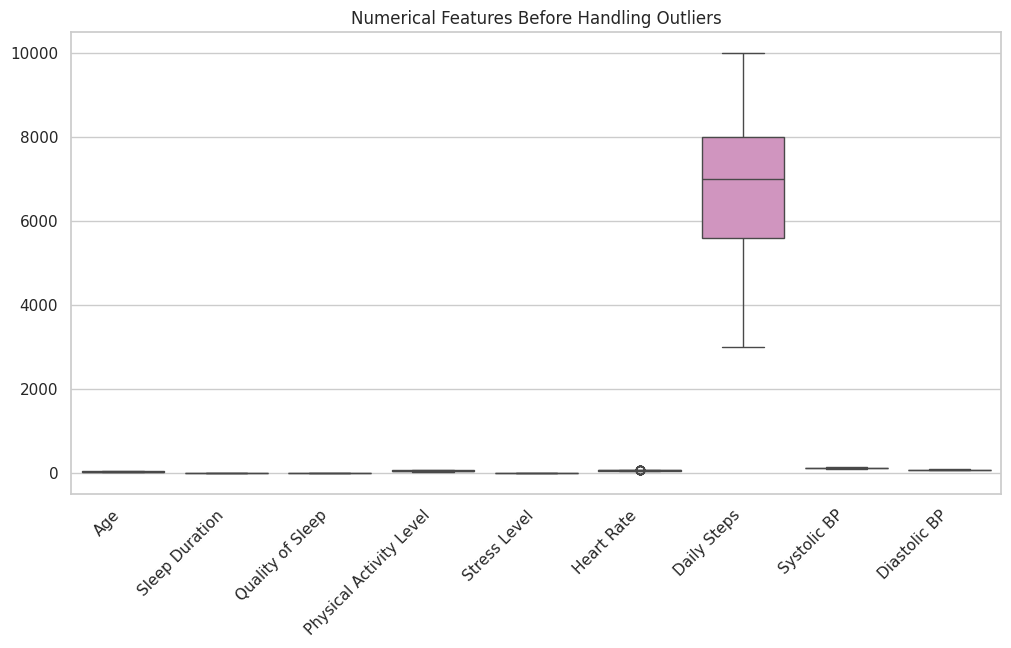

In [13]:
# Visualize the columns before handling outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[numerical_cols])
plt.xticks(rotation=45, ha="right")
plt.title("Numerical Features Before Handling Outliers")
plt.show()

## Handling Outliers

I used **capping** instead of deleting rows. This keeps the dataset size the same and reduces the effect of extreme values. Any value below the lower IQR bound is replaced with the lower bound, and any value above the upper bound is replaced with the upper bound.

In [14]:
df_no_outliers = df_clean.copy()

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lower_bound, upper=upper_bound)

# Check outliers again after capping
outlier_check_after = []

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_no_outliers[(df_no_outliers[col] < lower_bound) | (df_no_outliers[col] > upper_bound)]
    
    outlier_check_after.append({
        "Feature": col,
        "Outlier Count After Capping": outliers.shape[0]
    })

pd.DataFrame(outlier_check_after)

,Feature,Outlier Count After Capping
0,Age,0
1,Sleep Duration,0
2,Quality of Sleep,0
3,Physical Activity Level,0
4,Stress Level,0
5,Heart Rate,0
6,Daily Steps,0
7,Systolic BP,0
8,Diastolic BP,0


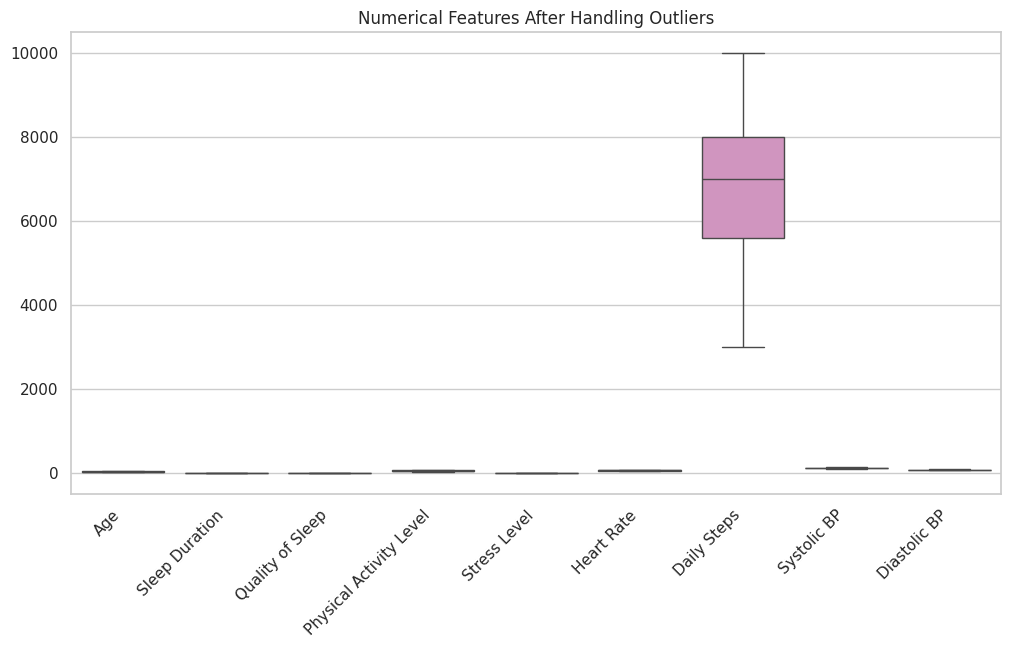

In [15]:
# Visualize the columns after handling outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_no_outliers[numerical_cols])
plt.xticks(rotation=45, ha="right")
plt.title("Numerical Features After Handling Outliers")
plt.show()

# Task 4: Normalize Numerical Features Using Min-Max and Z-score

I applied two scaling methods:

- **Min-Max normalization:** transforms values to a range between 0 and 1.
- **Z-score standardization:** transforms values based on the mean and standard deviation, so each feature has a mean close to 0 and standard deviation close to 1.

In [16]:
# Min-Max normalization
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df_no_outliers[numerical_cols])

minmax_df = pd.DataFrame(minmax_scaled, columns=[col + "_MinMax" for col in numerical_cols])
minmax_df.head()

,Age_MinMax,Sleep Duration_MinMax,Quality of Sleep_MinMax,Physical Activity Level_MinMax,Stress Level_MinMax,Heart Rate_MinMax,Daily Steps_MinMax,Systolic BP_MinMax,Diastolic BP_MinMax
0,0.00000,0.111111,0.4,0.2,0.6,0.923077,0.171429,0.407407,0.40
1,0.03125,0.148148,0.4,0.5,1.0,0.769231,1.000000,0.370370,0.25
2,0.03125,0.148148,0.4,0.5,1.0,0.769231,1.000000,0.370370,0.25
3,0.03125,0.037037,0.0,0.0,1.0,1.000000,0.000000,0.925926,0.75
4,0.03125,0.037037,0.0,0.0,1.0,1.000000,0.000000,0.925926,0.75


In [17]:
# Z-score standardization
zscore_scaler = StandardScaler()
zscore_scaled = zscore_scaler.fit_transform(df_no_outliers[numerical_cols])

zscore_df = pd.DataFrame(zscore_scaled, columns=[col + "_Zscore" for col in numerical_cols])
zscore_df.head()

,Age_Zscore,Sleep Duration_Zscore,Quality of Sleep_Zscore,Physical Activity Level_Zscore,Stress Level_Zscore,Heart Rate_Zscore,Daily Steps_Zscore,Systolic BP_Zscore,Diastolic BP_Zscore
0,-1.753096,-1.298887,-1.098280,-0.825418,0.347021,1.974677,-1.619584,-0.330002,-0.268102
1,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.413271,1.970077,-0.459239,-0.755640
2,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.413271,1.970077,-0.459239,-0.755640
3,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.255380,-2.362273,1.479309,0.869486
4,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.255380,-2.362273,1.479309,0.869486


In [18]:
# Compare original, Min-Max, and Z-score values for the first five records
comparison_df = pd.concat([
    df_no_outliers[numerical_cols].head().reset_index(drop=True),
    minmax_df.head().reset_index(drop=True),
    zscore_df.head().reset_index(drop=True)
], axis=1)

comparison_df

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP,Age_MinMax,Sleep Duration_MinMax,Quality of Sleep_MinMax,Physical Activity Level_MinMax,Stress Level_MinMax,Heart Rate_MinMax,Daily Steps_MinMax,Systolic BP_MinMax,Diastolic BP_MinMax,Age_Zscore,Sleep Duration_Zscore,Quality of Sleep_Zscore,Physical Activity Level_Zscore,Stress Level_Zscore,Heart Rate_Zscore,Daily Steps_Zscore,Systolic BP_Zscore,Diastolic BP_Zscore
0,27,6.1,6,42,6,77,4200,126,83,0.00000,0.111111,0.4,0.2,0.6,0.923077,0.171429,0.407407,0.40,-1.753096,-1.298887,-1.098280,-0.825418,0.347021,1.974677,-1.619584,-0.330002,-0.268102
1,28,6.2,6,60,8,75,10000,125,80,0.03125,0.148148,0.4,0.5,1.0,0.769231,1.000000,0.370370,0.25,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.413271,1.970077,-0.459239,-0.755640
2,28,6.2,6,60,8,75,10000,125,80,0.03125,0.148148,0.4,0.5,1.0,0.769231,1.000000,0.370370,0.25,-1.637643,-1.173036,-1.098280,0.039844,1.475592,1.413271,1.970077,-0.459239,-0.755640
3,28,5.9,4,30,8,78,3000,140,90,0.03125,0.037037,0.0,0.0,1.0,1.000000,0.000000,0.925926,0.75,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.255380,-2.362273,1.479309,0.869486
4,28,5.9,4,30,8,78,3000,140,90,0.03125,0.037037,0.0,0.0,1.0,1.000000,0.000000,0.925926,0.75,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.255380,-2.362273,1.479309,0.869486


# Task 5: Apply PCA and Interpret Explained Variance

PCA works better when numerical features are standardized, so I used the **Z-score scaled data** for PCA. This prevents larger-scale features like `Daily Steps` from dominating smaller-scale features like `Sleep Duration`.

In [19]:
pca = PCA()
pca_result = pca.fit_transform(zscore_df)

explained_variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance_df

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.398986,0.398986
1,PC2,0.310343,0.709329
2,PC3,0.172485,0.881814
3,PC4,0.055411,0.937226
4,PC5,0.032089,0.969315
5,PC6,0.014591,0.983906
6,PC7,0.008378,0.992284
7,PC8,0.006300,0.998584
8,PC9,0.001416,1.000000


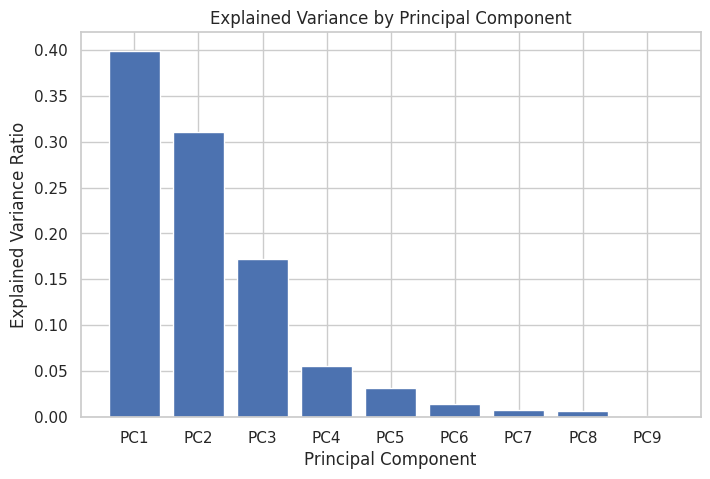

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(
    explained_variance_df["Principal Component"],
    explained_variance_df["Explained Variance Ratio"]
)
plt.title("Explained Variance by Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.show()

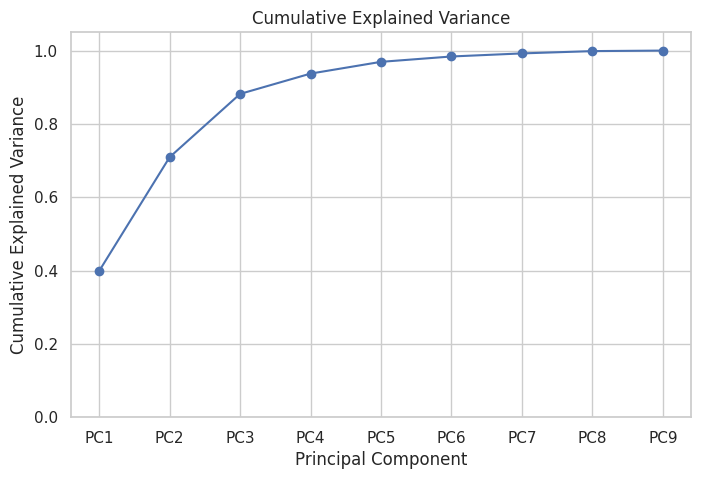

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance_df["Principal Component"],
    explained_variance_df["Cumulative Explained Variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance")
plt.ylabel("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [22]:
# Create a 2D PCA dataframe using the first two components
pca_2d_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Sleep Disorder": df_no_outliers["Sleep Disorder"]
})

pca_2d_df.head()

,PC1,PC2,Sleep Disorder
0,-2.474351,-1.767747,No Disorder
1,-2.816948,-0.788432,No Disorder
2,-2.816948,-0.788432,No Disorder
3,-4.392568,-0.718475,Sleep Apnea
4,-4.392568,-0.718475,Sleep Apnea


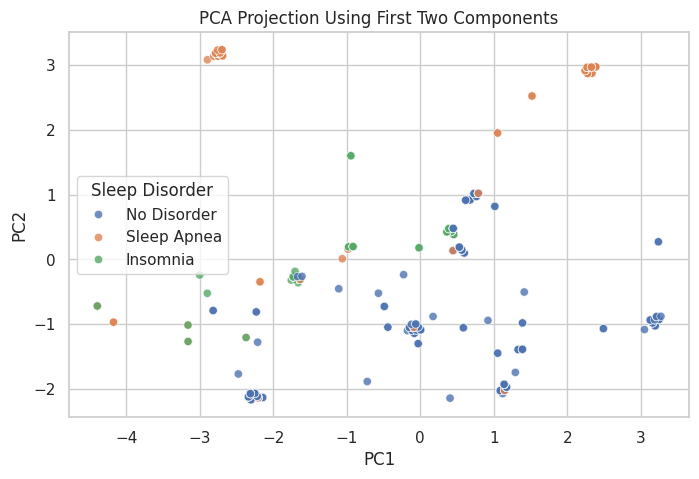

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_2d_df, x="PC1", y="PC2", hue="Sleep Disorder", alpha=0.8)
plt.title("PCA Projection Using First Two Components")
plt.show()

## PCA Interpretation

The first principal component explains the largest part of the variance in the dataset, which means it captures the strongest overall pattern across the numerical features. The second component explains the next largest part, but less than the first one.

The cumulative explained variance shows how many components are needed to keep most of the information. If the first few components explain a high percentage of the variance, then PCA can reduce the number of dimensions while still keeping the main structure of the data. In this dataset, PCA helps summarize the health and lifestyle numerical features into fewer components instead of using every numerical column separately.

# Final Summary

In this assignment, I used the same Sleep Health and Lifestyle dataset from Assignment 1 and prepared it for machine learning preprocessing. I found missing values in `Sleep Disorder`, a text format issue in `Blood Pressure`, inconsistent BMI category naming, repeated profiles, and some outliers in numerical features. I replaced missing sleep disorder values with `No Disorder`, split blood pressure into numerical columns, handled outliers using IQR capping, normalized numerical features using Min-Max and Z-score, and applied PCA to understand the explained variance.